# Customer Churn Prediction

## Exploratory Data Analysis (EDA)

### Project Objective

The objective of this notebook is to understand the IBM Telco Customer Churn dataset by analyzing its structure, identifying data quality issues, exploring customer characteristics, and discovering patterns associated with customer churn.

---


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 7043
Columns : 21


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [8]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


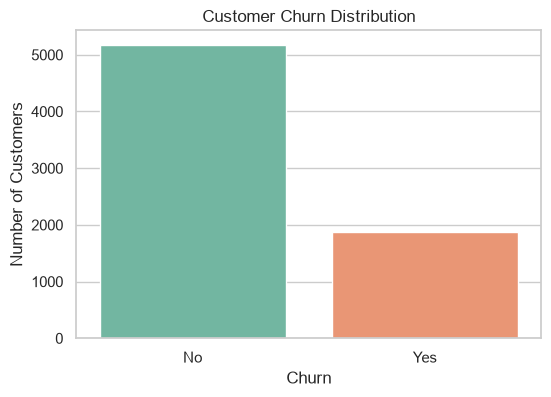

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [10]:
# Count of each class
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
# Percentage of each class
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

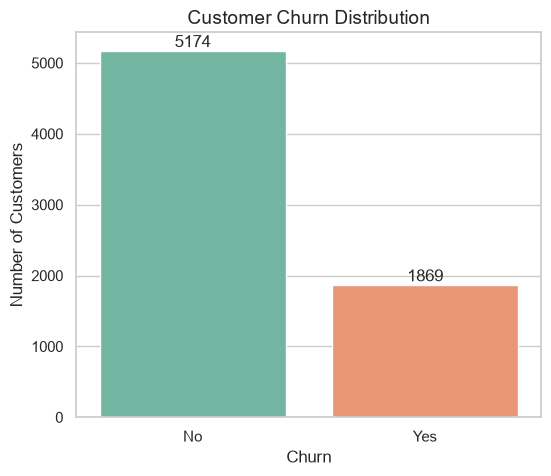

In [12]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [13]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(numerical_cols)

print("\nCategorical Features")
print(categorical_cols)

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Features
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [14]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

customerID: 7043 unique values
gender: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


In [15]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [16]:
df["TotalCharges"].describe()

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

In [17]:
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

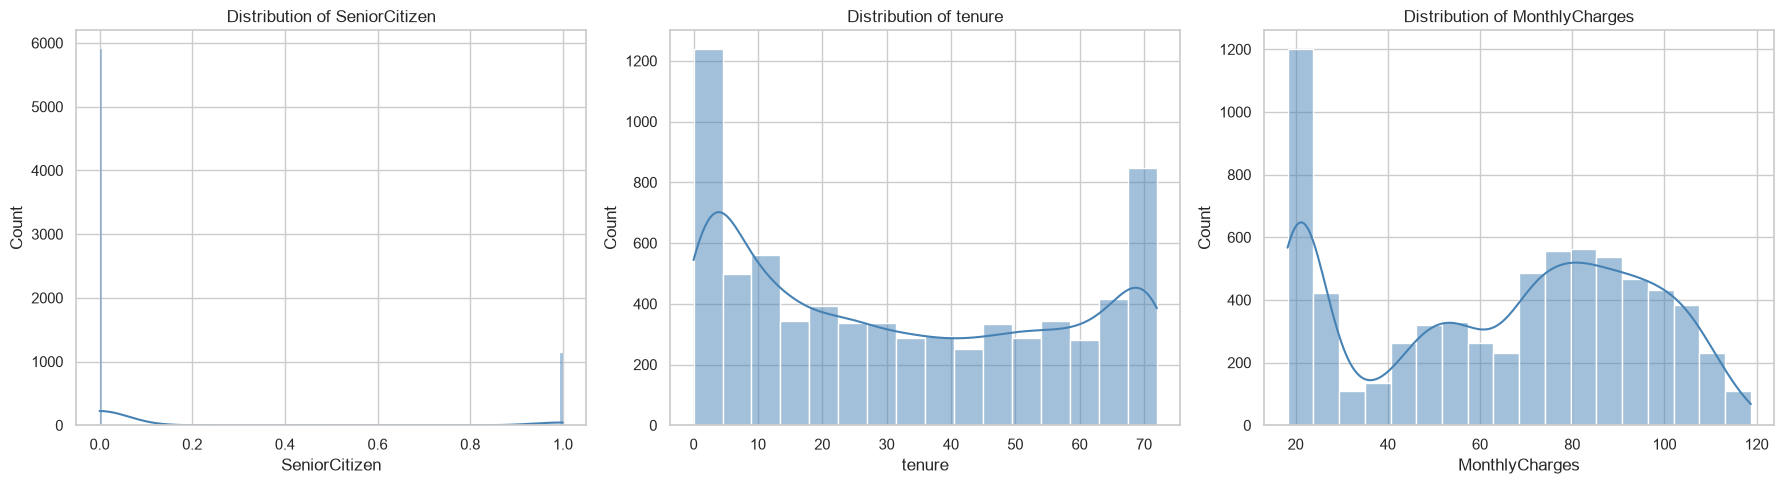

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color="steelblue",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

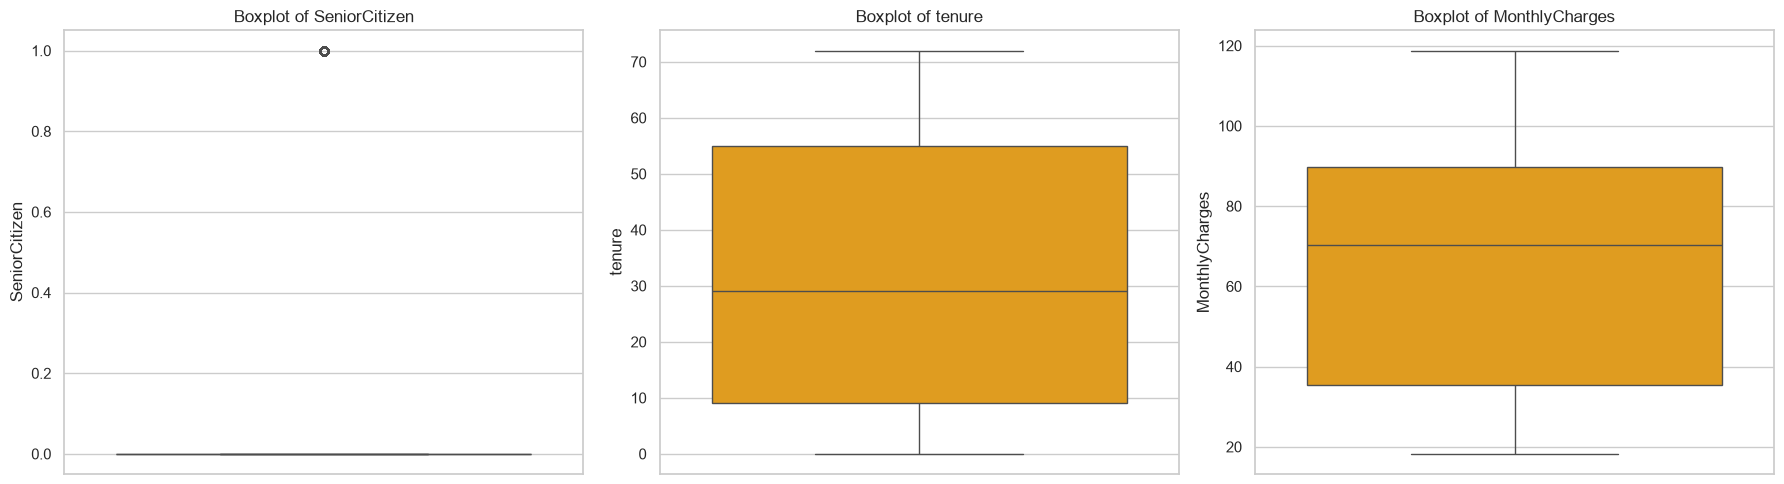

In [19]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        y=df[col],
        color="orange",
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

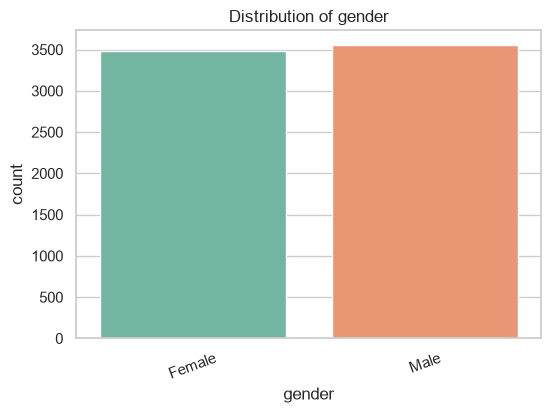

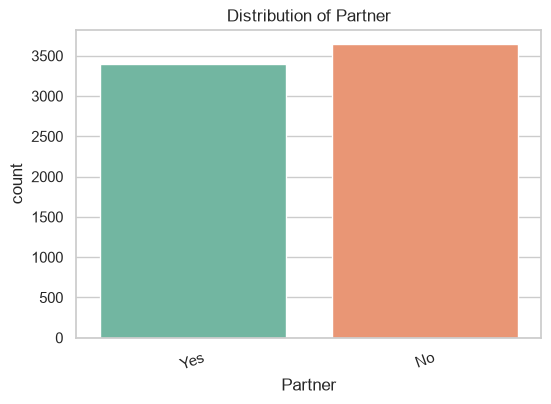

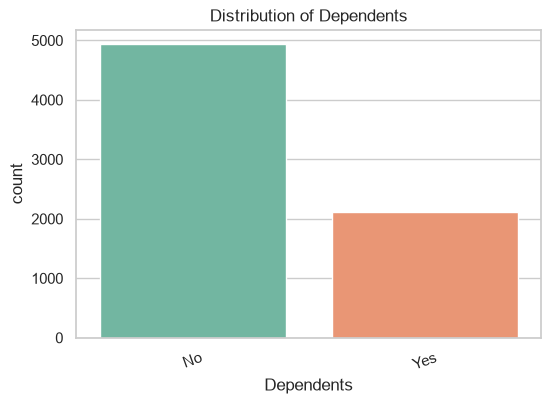

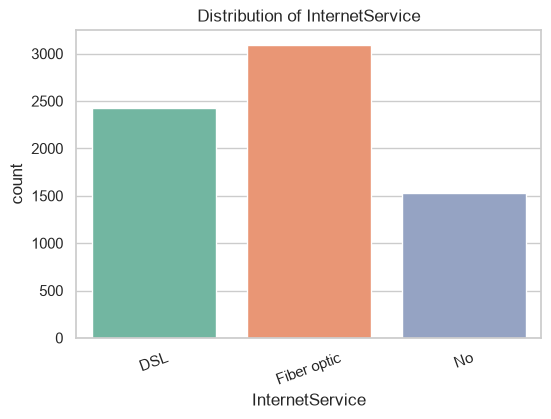

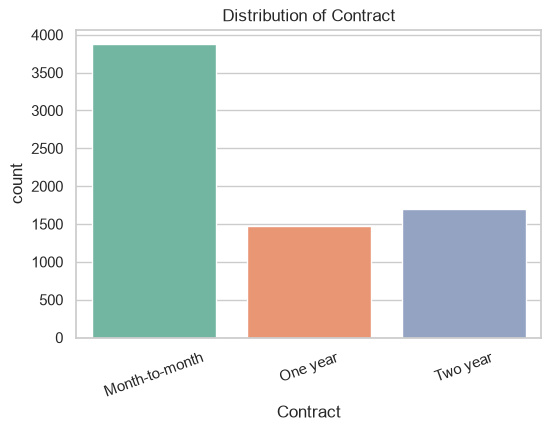

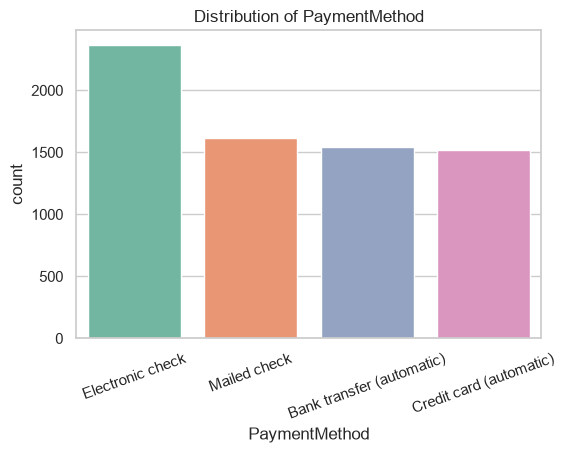

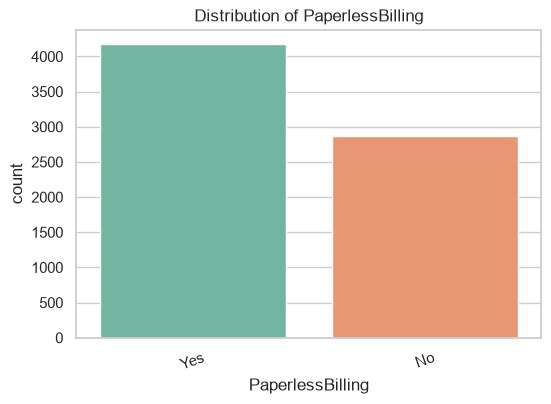

In [20]:
important_cat = [
    "gender",
    "Partner",
    "Dependents",
    "InternetService",
    "Contract",
    "PaymentMethod",
    "PaperlessBilling"
]

for col in important_cat:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,
        palette="Set2"
    )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=20)

    plt.show()

In [21]:
churn_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "Partner",
    "Dependents",
    "gender"
]

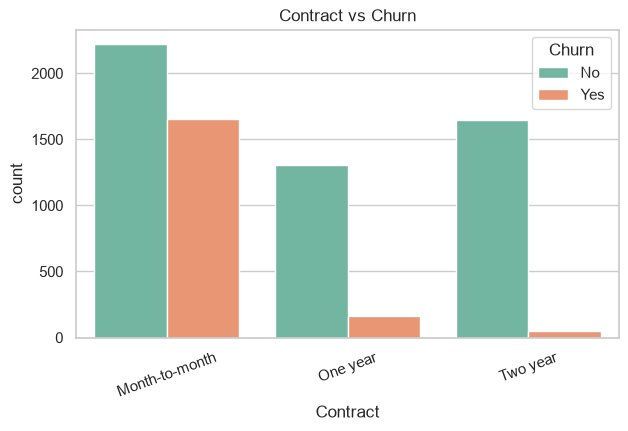

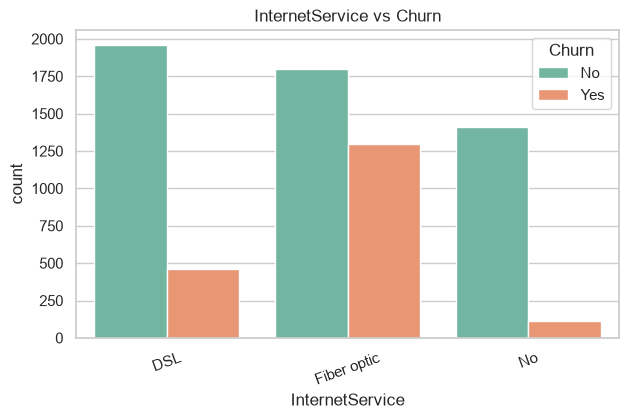

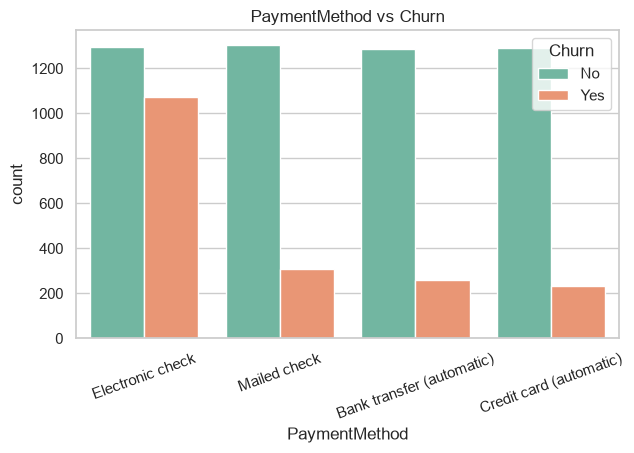

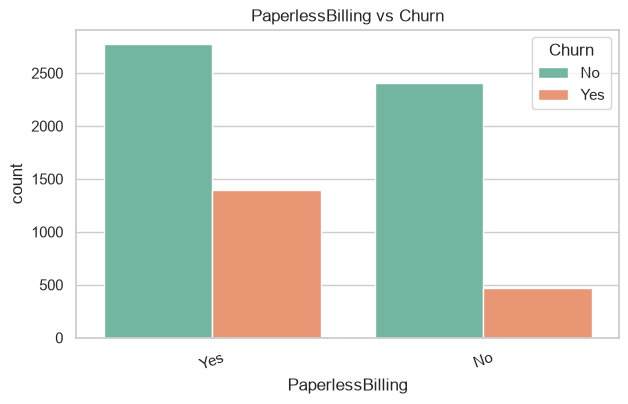

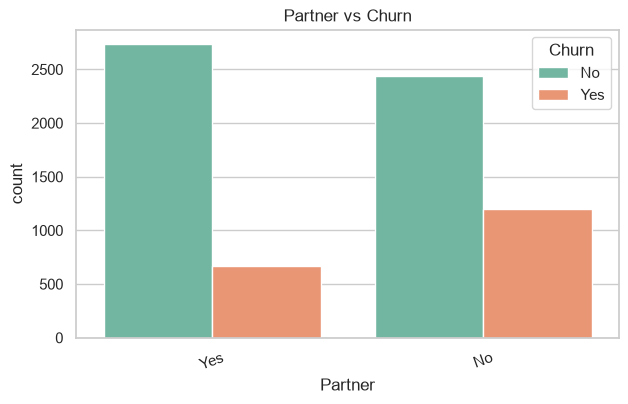

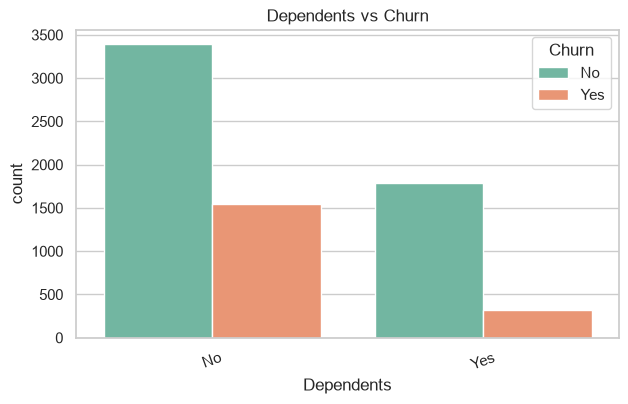

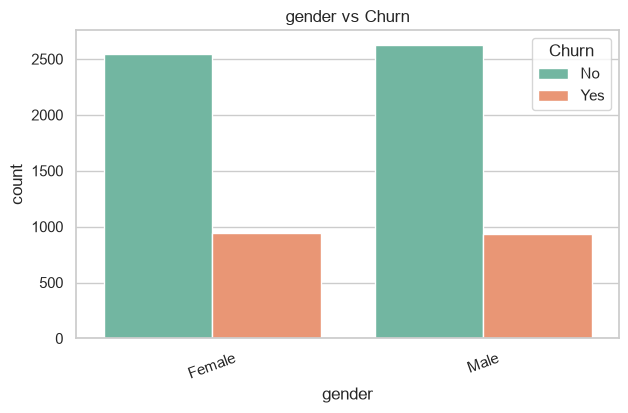

In [22]:
for col in churn_features:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        palette="Set2"
    )

    plt.title(f"{col} vs Churn")

    plt.xticks(rotation=20)

    plt.show()

<Axes: xlabel='Churn', ylabel='tenure'>

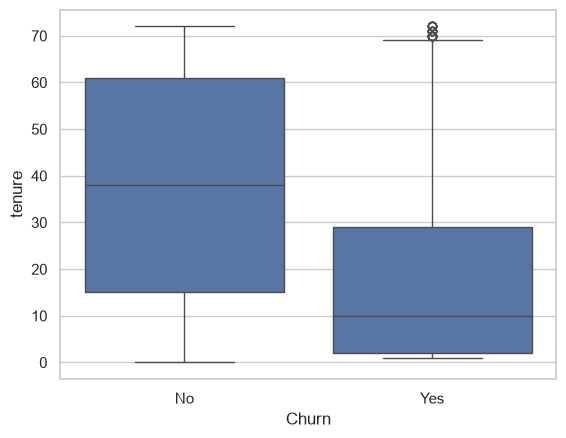

In [23]:
sns.boxplot(data=df, x="Churn", y="tenure")

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

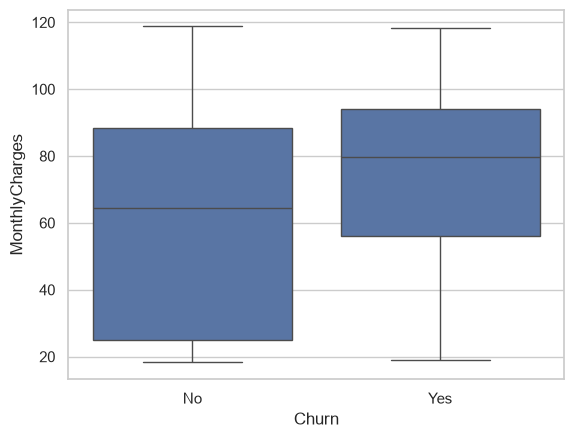

In [24]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

In [25]:
# Temporary conversion for EDA
eda_df = df.copy()

eda_df["TotalCharges"] = pd.to_numeric(
    eda_df["TotalCharges"],
    errors="coerce"
)

In [26]:
eda_df["TotalCharges"].isnull().sum()

np.int64(11)

In [27]:
numerical_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

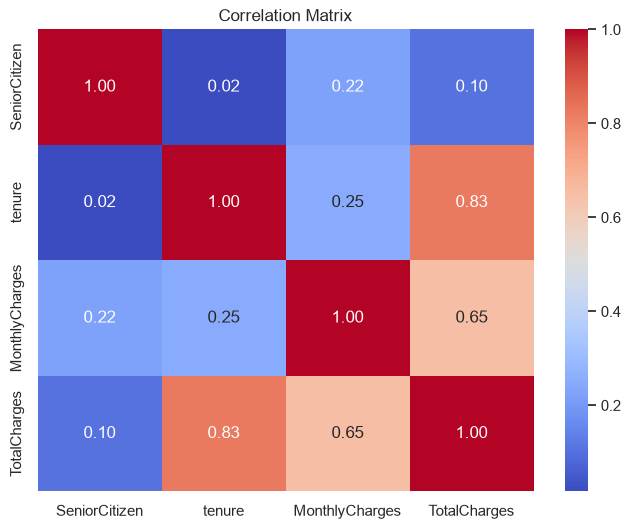

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    eda_df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [29]:
eda_df["Churn_Binary"] = eda_df["Churn"].map({
    "No":0,
    "Yes":1
})

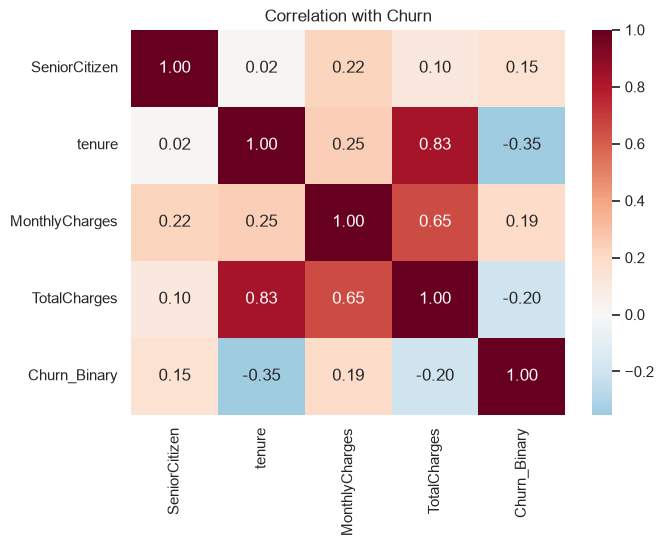

In [30]:
corr = eda_df[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn_Binary"
    ]
].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Correlation with Churn")

plt.show()

In [31]:
from sklearn.preprocessing import LabelEncoder

encoded_df = eda_df.copy()

le = LabelEncoder()

for col in encoded_df.select_dtypes(include="object").columns:
    encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))

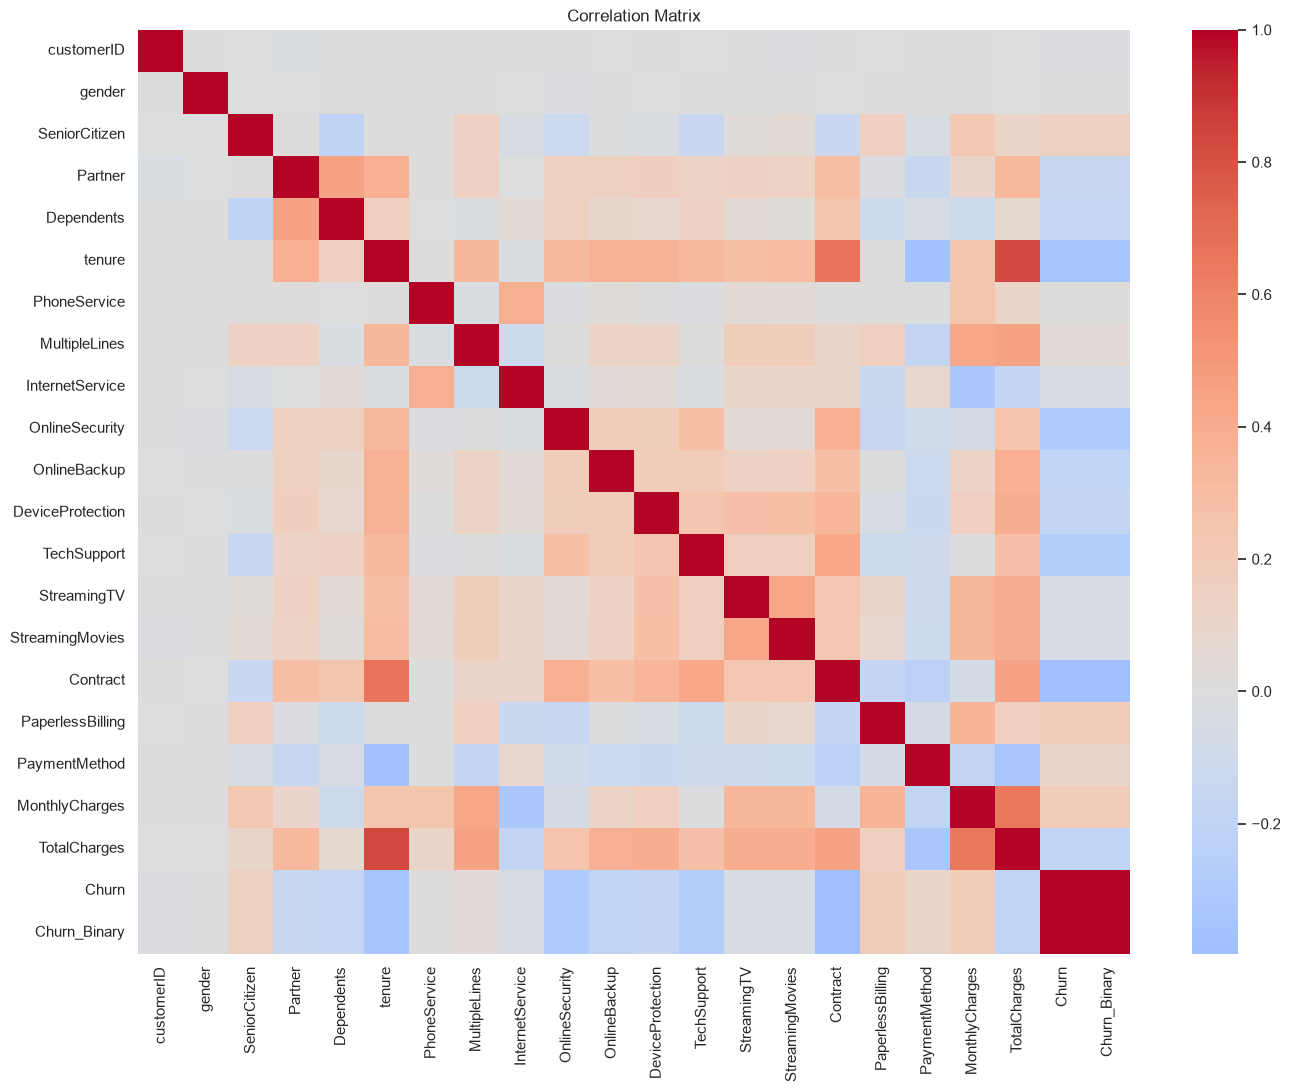

In [32]:
corr = encoded_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [34]:
churn_corr = (
    corr["Churn"]
    .sort_values(ascending=False)
)

print(churn_corr)

Churn               1.000000
Churn_Binary        1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
customerID         -0.017447
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199484
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


In [35]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## Correlation Analysis Summary

The strongest negative relationship with churn was observed for **Contract** (-0.397), followed by **tenure** (-0.352). This suggests that customers with longer contracts and longer subscription periods are less likely to leave the company.

Features such as **OnlineSecurity** and **TechSupport** also show moderate negative correlations, indicating that value-added services may improve customer retention.

On the other hand, **MonthlyCharges** and **PaperlessBilling** show positive correlations with churn, suggesting that customers paying higher monthly fees are more likely to leave.